### Business objective:
>- Risk assessment: Classify individuals into categories (standard, poor, good) to evaluate their likelihood of repaying loans.
>- Tailored offerings: Based on the predicted credit score, offer customized loan terms, interest rates, or financial products.
>- Fraud prevention and defaults: Identify individuals with poor credit scores to minimize defaults and financial risk.

## Model building on credit score data<a class="anchor" id ="steps"></a>
## steps
[Data preprocessing](#step1)<br>
[Build a decision tree model](#step2)<br>
[model evaluation](#step3)<br>
[Hyperparameter tuning](#step4)<br>
[Feature Importances](#step5)<br>
[Random Forest](#step6)<br>


In [3]:
import os
import zipfile
import chardet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [55]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split,cross_val_predict
from sklearn.pipeline import make_pipeline,Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer


In [5]:
from sklearn.feature_selection import SelectFromModel

In [6]:
from sklearn import metrics

In [7]:
from sklearn.metrics import matthews_corrcoef

In [79]:
# Set pandas option to display all columns
pd.set_option('display.max_columns', None)  # Show all columns

#read in csv file
csv_file= 'Credit Score Data/train.csv'
zip_path = 'Credit-Score-Data.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open(csv_file) as file:
        df = pd.read_csv(file)

#remove high cardinality and redundant features
df.drop(columns = ['ID','Customer_ID','Name','SSN',], inplace = True)
print(df.shape)
df.head(3)

(100000, 24)


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,1,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,2,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,4.0,11.27,4.0,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,3,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good


### Step 1: Data Preprecessing<a class="anchor" id="step1"></a>

[go_back_up](#steps)

In [81]:
#spliting the data
target = 'Credit_Score'
#apply encoding on the target
labelencoder = LabelEncoder()
y = labelencoder.fit_transform(df[target].values)
X = df.drop(columns = 'Credit_Score')

#split data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
print(y.shape,X.shape)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(100000,) (100000, 23)
(80000, 23) (20000, 23) (80000,) (20000,)


In [83]:
#keeping less frequent categories as other
#chose 60 as a threhold because below 60 contained more than 3 loans taken
threshold = 60
top_categories = X_train['Type_of_Loan'].value_counts()[X_train['Type_of_Loan'].value_counts() >= threshold].index
X_train['Type_of_Loan'] = X_train['Type_of_Loan'].apply(lambda x: x if x in top_categories else 'multiple_loans')
#X_train['Type_of_Loan'].value_counts()

#using frequency encoding 
X_train['loan_type_encoded'] = X_train['Type_of_Loan'].map(X_train['Type_of_Loan'].value_counts())
#X_train['loan_type_encoded'].nunique()
#drop the type of loan column
X_train.drop(columns ='Type_of_Loan', inplace = True)

In [12]:
X_train.select_dtypes('object').nunique()

Occupation               15
Credit_Mix                3
Payment_of_Min_Amount     3
Payment_Behaviour         6
dtype: int64

In [13]:
#baseline model
acc_baseline = pd.Series(y_train).value_counts(normalize = True).max()
print("Baseline Accuracy:", round(acc_baseline, 4))

Baseline Accuracy: 0.5322


### Build a decision tree<a class="anchor" id="step2"></a>

[go_back_up](#steps)

In [53]:
#fit decision tree 
num_columns = X_train.select_dtypes('number').columns
cat_columns = X_train.select_dtypes('object').columns
# Set up the ColumnTransformer to encode categorical features
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(), cat_columns),
                 ('num','passthrough',num_columns)])  # Keep other columns (e.g., numerical) as they are

# Define the pipeline with preprocessing, feature selection and the classifier
tree = Pipeline(steps=[('preprocessor', preprocessor),
                       ('feature_selection',SelectFromModel(DecisionTreeClassifier(),threshold="median")),
                       ('classifier', DecisionTreeClassifier(max_depth = 10,
                                                             max_features = 'log2',
                                                             min_samples_leaf = 5,
                                                             min_samples_split = 5,
                                                             random_state=42))])
# Fit on `X_train`, `y_train`
tree.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  Index(['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Month', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_da...
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance', 'loan_type_encoded'],
      dtype='object'))])),
                ('feature_selection',
                 SelectFromModel(estimator=DecisionTreeClassifier(),
                                 threshold='median')),
                ('classifier',
                 DecisionTreeClassifier(max_depth=10, max_features='log2',
                                        min_samples_leaf=5, min_samples_split=5,
                                        random_state=42))])

## Model evaluation<a class="anchor" id="step3"></a>

[go_back_up](#steps)

In [57]:
#evaluate using cross validation
scores = cross_val_score(tree, X_train,y_train, cv=5)
print('Accuracy score of each fold: {}'.format(scores))

#compute the mean of thescores
print('Average cross validation score: {:.2f}'.format(scores.mean()))

# Compute MCC using cross-validation predictions
y_pred_cv = cross_val_predict(tree, X_train, y_train, cv=5)
mcc = matthews_corrcoef(y_train, y_pred_cv)
print('MCC (cross-validated):', round(mcc, 3))


Accuracy score of each fold: [0.68175   0.70475   0.694875  0.690125  0.6808125]
Average cross validation score: 0.69
MCC (cross-validated): 0.484


In [63]:
#classification report
target_names = ['Standard', 'Poor', 'Good']
print(classification_report(y_train, y_pred_cv, target_names=target_names))


              precision    recall  f1-score   support

    Standard       0.55      0.63      0.59     14301
        Poor       0.71      0.63      0.67     23124
        Good       0.73      0.74      0.74     42575

    accuracy                           0.69     80000
   macro avg       0.66      0.67      0.66     80000
weighted avg       0.69      0.69      0.69     80000



In [40]:
tree.named_steps['classifier'].get_depth()

10

### Hyperparameter tuning<a class="anchor" id="step4"></a>

[go_back_up](#steps)

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the parameter distribution
param_dist = {
    'classifier__max_depth': [5, 10, 20],
    'classifier__min_samples_split': randint(2, 20),
    'classifier__min_samples_leaf': randint(1, 20),
    'classifier__max_features': ['sqrt', 'log2'],
    
}

# Set up RandomizedSearchCV
#using scoring='f1_samples' bse it is multi-class classification problem and imbalanced dataset
random_search = RandomizedSearchCV(estimator=tree, param_distributions=param_dist, n_iter=100, cv=5, scoring='f1_samples',n_jobs =-1)

# Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Hyperparameters:", random_search.best_params_)


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Hyperparameters: {'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 5}


### Feature importances<a class="anchor" id="step5"></a>

[go_back_up](#steps)

In [84]:
#feature selection using feature importance
importance = pd.DataFrame(tree.named_steps['classifier'].feature_importances_,
                          index = tree.named_steps['preprocessor'].get_feature_names_out(input_features=X_train.columns), 
                          columns = ["Importance"]).sort_values(by= "Importance", ascending= False)
importance.head()

,Importance
num__Num_Credit_Inquiries,0.207237
cat__Credit_Mix_Standard,0.204305
num__Outstanding_Debt,0.100945
num__Credit_History_Age,0.051314
num__Delay_from_due_date,0.050958


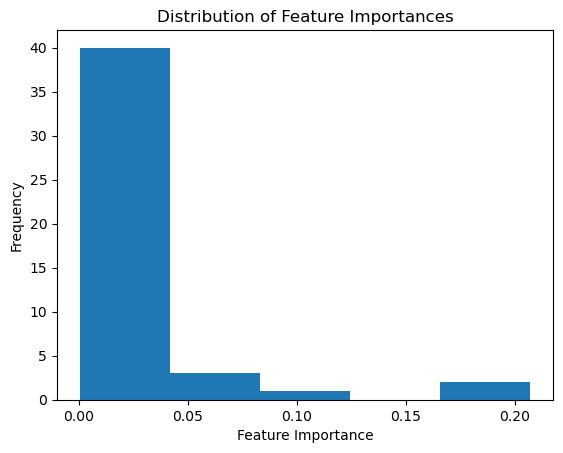

In [100]:
#distribution of feature importance
plt.hist(importance, bins=5)
plt.xlabel("Feature Importance")
plt.ylabel("Frequency")
plt.title("Distribution of Feature Importances")
plt.show();

### Random Forest<a class="anchor" id="step6"></a>

[go_back_up](#steps)

In [65]:
#fit Random forest
num_columns = X_train.select_dtypes('number').columns
cat_columns = X_train.select_dtypes('object').columns
# Set up the ColumnTransformer to encode categorical features
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(), cat_columns),
                 ('num','passthrough',num_columns)])  # Keep other columns (e.g., numerical) as they are

# Define the pipeline with preprocessing, feature selection and the classifier
forest = Pipeline(steps=[('preprocessor', preprocessor),
                       ('feature_selection',SelectFromModel(RandomForestClassifier(),threshold="median")),
                       ('classifier', RandomForestClassifier(n_estimators = 242,
                                                             max_depth = 10,
                                                             max_features = 'sqrt',
                                                             min_samples_leaf = 18,
                                                             min_samples_split = 15,
                                                             random_state=42))])
# Fit on `X_train`, `y_train`
forest.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  Index(['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Month', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_da...
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance', 'loan_type_encoded'],
      dtype='object'))])),
                ('feature_selection',
                 SelectFromModel(estimator=RandomForestClassifier(),
                                 threshold='median')),
                ('classifier',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=18,
                                        min_samples_split=15, n_estimators=242,
                                        random_state=42))])

In [67]:
#evaluate using cross validation
scores = cross_val_score(forest, X_train,y_train, cv=5)
print('Accuracy score of each fold: {}'.format(scores))

#compute the mean of thescores
print('Average cross validation score: {:.2f}'.format(scores.mean()))

# Compute MCC using cross-validation predictions
y_pred_cvf = cross_val_predict(forest, X_train, y_train, cv=5)
mcc = matthews_corrcoef(y_train, y_pred_cvf)
print('MCC (cross-validated):', round(mcc, 3))

Accuracy score of each fold: [0.72125   0.7306875 0.7224375 0.7269375 0.718875 ]
Average cross validation score: 0.72
MCC (cross-validated): 0.552


In [69]:
#classification report
target_names = ['Standard', 'Poor', 'Good']
print(classification_report(y_train, y_pred_cvf, target_names=target_names))


              precision    recall  f1-score   support

    Standard       0.58      0.76      0.66     14301
        Poor       0.75      0.67      0.71     23124
        Good       0.78      0.74      0.76     42575

    accuracy                           0.72     80000
   macro avg       0.70      0.72      0.71     80000
weighted avg       0.73      0.72      0.73     80000



In [56]:
#hyperparameter tuning
# Define the parameter distribution
param_dist = {
    'classifier__max_depth': [5, 10, 20],
    'classifier__min_samples_split': randint(2, 20),
    'classifier__min_samples_leaf': randint(1, 20),
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__n_estimators': randint(50, 500)
    
}

# Set up RandomizedSearchCV
#using scoring='f1_samples' bse it is multi-class classification problem and imbalanced dataset
random_search = RandomizedSearchCV(estimator=forest, param_distributions=param_dist, n_iter=100, cv=5, scoring='f1_samples',n_jobs =-1)

# Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Hyperparameters:", random_search.best_params_)


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Hyperparameters: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 18, 'classifier__min_samples_split': 15, 'classifier__n_estimators': 242}


### model evaluation on test data

In [89]:
#transforming x_test in the same way x_train was transformed
#grouping less frequent categories
X_test['Type_of_Loan'] = X_test['Type_of_Loan'].apply(lambda x: x if x in top_categories else 'multiple_loans')
#Apply the Same Frequency Encoding
X_test['loan_type_encoded'] = X_test['Type_of_Loan'].map(X_test['Type_of_Loan'].value_counts())
#Handle Unseen Categories in X_test
X_test['loan_type_encoded'].fillna(X_train['loan_type_encoded'].min(), inplace=True)
#Drop Type_of_Loan (Just Like X_train)
X_test.drop(columns='Type_of_Loan', inplace=True)


In [133]:
#  Apply the preprocessing (transform X_test)
X_test_transformed = forest.named_steps['preprocessor'].transform(X_test)

#  Get feature names after transformation (using get_feature_names_out())
transformed_feature_names = forest.named_steps['preprocessor'].get_feature_names_out()

# Apply feature selection (transform X_test_transformed)
X_test_selected = forest.named_steps['feature_selection'].transform(X_test_transformed)

#  Get selected feature names
selected_columns = transformed_feature_names[forest.named_steps['feature_selection'].get_support()]

#  Convert X_test_selected (which is numpy array) to DataFrame with selected columns
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_columns)

#  Now evaluate using the forest pipeline (use .score for direct evaluation)
accuracy = forest.named_steps['classifier'].score(X_test_selected_df, y_test)
print(f'Accuracy on Test Data: {accuracy:.2f}')




C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Accuracy on Test Data: 0.73


In [135]:
# Evaluate using the Matthews Correlation Coefficient 
# Make predictions
y_pred_test = forest.named_steps['classifier'].predict(X_test_selected_df)
mcc = matthews_corrcoef(y_test, y_pred_test)
print('MCC:', round(mcc, 3))

# Classification report
target_names = ['Standard', 'Poor', 'Good']
print(classification_report(y_test, y_pred_test, target_names=target_names))


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


MCC: 0.569
              precision    recall  f1-score   support

    Standard       0.57      0.77      0.66      3527
        Poor       0.74      0.72      0.73      5874
        Good       0.80      0.72      0.76     10599

    accuracy                           0.73     20000
   macro avg       0.71      0.74      0.72     20000
weighted avg       0.74      0.73      0.73     20000



### conclusion
>-Slight Increase in MCC on Test Data: The fact that the MCC on the test data (0.569) is slightly higher than on the train data (0.552) indicates that the model is generalizing well. There's no significant overfitting happening because your test performance is close to the training performance, and in fact, it is a little better.

>-Model Stability: The small difference suggests that the model is stable and is not overly biased towards the training data, as we would expect a larger gap if the model was overfitting.

>-Good Generalization: A higher MCC on the test set than the training set could mean the model is learning the general patterns rather than memorizing the training data, which is a positive sign.

>-Overall, this comparison suggests that your Random Forest classifier is performing well and generalizing effectively on unseen data.

## save our model

In [139]:
import pickle

# Save the model(pipeline)
with open('credit_score_model.pkl', 'wb') as f:
    pickle.dump(forest, f)
